## Implementierung eines vereinfachten Hough-Circle-Algorithmuses zur Kreisdetektion.

Der hier umzusetzende Hough-Circle-Algorithmus detektiert nur kreise eines speziellen, vorher bekanntem, Radius im Bild. Wie in der Vorlesung vorgestellt erfolgt die Implementierung in 3 Schritten.

1. Kantendetektion mittels Canny-Edge-Detektor
2. Erzeugen des Akkumulatorbildes
3. Lokalisierung der Kreismittelpunkte durch Schwellenwertbildung

Zu Schritt 2: In dieser Übung wird das Akkumulator-Bild nur für einen vorgegebenen Kreisradius erzeugt. Dazu wird für jeden Kantenpunkt im Bild der Kreis mit dem vorgegebenen Radius in das Akkumulatorbild "gezeichnet". Hierzu wird ein weiteres Hilfsbild verwendet. Dieses Bild mit einem Kreis des wird dann an die Position eines jeden Kantenpunktes gelegt und dessen Pixelwerte dann zum Akkumulatorbild addiert.

### Aufgabe:
<div style="text-align: center;">
    <img src="./Images/circles.png" width="15%">
    <p style="font-style: italic;">Abbildung 1: Eingangsbild mit 25 Kreisen unterschiedlicher Radien</p>
</div>

Das Bild zeigt insgesamt 25 Kreise fast gleicher Größe. 23 der Kreise haben einen **Radius von 50 Pix**. , währen ein Kreis etwas größer ist (**Radius 55 Pix.**) und ein weiterer Kreis etwas kleiner ist (**Radius 45 Pix.**). Ihre Aufgabe ist es den Hough  - Algorithmus zu implementieren und dann die Kreise mit den unterschiedlichen Radien zu detektieren und farblich zu markieren.

<div style="text-align: center;">
    <img src="./Images/results/circles_detected.png" width="15%">
    <p style="font-style: italic;">Abbildung 2: Detektierte Kreise mit farblicher Markierung</p>
</div>



In [1]:
# package import
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import skimage
from modules.plotting import displayImagePlotly
import matplotlib.pyplot as plt
import matplotlib


In [2]:
# load and display image
img = cv2.imread('images/circles.png', cv2.IMREAD_GRAYSCALE)
displayImagePlotly(img, title='Kreis Bild')

#Datentyp:
imageDataType = img.dtype 
#Bildgröße
imageShape =  img.shape  

# Ausgabe der Daten
print(f'Datentyp des Bildes: {imageDataType}')
print(f'Größe des Bildes: {imageShape}')


Datentyp des Bildes: uint8
Größe des Bildes: (1000, 1000)


## Umsetzung:

### Schritt 1: Kantendetektion

Verwenden Sie die Funktion `skimage.feature.canny(img, sigma=?)` mit einem geeigneten Wert für `sigma`, um die Kanten im Bild zu detektieren. Zeigen Sie das Bild an und überprüfen Sie Ihr Zwischenergebnis. 


In [3]:
####
## ENTER YOUR CODE HERE
####

# detect edges using Canny edge detector 
# img_edges 
img_edges = skimage.feature.canny(img, sigma=2)

# display edges image
# displayImagePlotly(img_edges, title='Kantenbild')

displayImagePlotly(img_edges, title='Kantenbild')

### Schritt 2: Erzeugen des Akkumulatorbildes

#### 2.1 Generierung eines Kreisbildes als Hilfsbild

##### Aufgabe:
Implementieren Sie die Funktion `create_circle_image(radius: int) -> np.ndarray: int`, die ein binäres Bild mit einem Kreis des angegebenen Radius erzeugt. Der Kreis soll im Zentrum des Bildes positioniert sein. Die Größe des Bildes soll so gewählt werden, dass der Kreis vollständig darin Platz findet (d.h. Bildgröße = 2 * Radius + 1).

Erzeugen Sie danach ein Kreisbild mit Radius 55 Pix. und zeigen Sie dieses Bild an.

***Hinweis:***\
die Funktion `skimage.draw.circle_perimeter(cx, cy, R)` kann zur Erzeugung eines Kreises verwendet werden. [https://scikit-image.org/docs/0.25.x/api/skimage.draw.html#skimage.draw.circle_perimeter](https://scikit-image.org/docs/0.25.x/api/skimage.draw.html#skimage.draw.circle_perimeter). Dieser Funktion werden Radius und Mittelpunktskoordinaten des Kreises übergeben.\
Rückgabewert der Funktion sind dan zwei Koordinatenlisten (rr,cc) die die jeweiligen x / y Komponenten der auf der Kreiskontur liegenden Pixelkoordinaten angeben.\
Im der Funktionsbeschreibung finden Sie ein Beispiel wie diese Koordinaten dann zum Zeichnen eines Kreises verwendet werden können.


*Nach erfolgreicher Implementierung sollte das Bild so aussehen*

<div style="text-align: center;">
    <img src="./Images/results/circle_template.png" width="15%">
    <p style="font-style: italic;">Abbildung 3: Kreis Bild Schablone</p>
</div>

In [4]:
def createCircleImage(radius):
    """Create binary image with circle perimeter.
    
    Args:
        radius (int): Circle radius in pixels. 
    
    Returns:
        Binary image with 0 and 1 values showing the circle outline.
    """
    # define center of the circle 
    center = (radius, radius)

    # create empty image
    img = np.zeros((2*radius+1,2*radius+1))

    # get perimeter pixel coordinates
    rr, cc  = skimage.draw.circle_perimeter(radius, radius, radius)
    
    # set circle perimeter pixels to 1
    img[rr,cc] = 1

    return img.astype('int')

In [5]:

# create circle image with radius 55
img_circ55 = createCircleImage(55)

# display circle image. !!!! Do not use displayImagePlotly here !!!!
fig = px.imshow(img_circ55, color_continuous_scale='gray', title = 'Kreis Bild')
fig.update_layout(
width = 500,
height = 500)
fig.show()

#### 2.2 Erzeugen des Akkumulatorbildes

##### Aufgabe: 

implementieren Sie eine Funktion  `calculateCircAccumulator(edges, img_circ) -> accumulator`, die das Akkumulatorbild für den angegebenen Radius berechnet. Verwenden Sie dazu das in Schritt 2.1 erzeugte Kreisbild als Vorlage. Legen Sie dazu für jeden Kantenpunkt im Kantenbild das Kreisbild an die Position des Kantenpunktes im Akkumulatorbild und addieren Sie die Pixelwerte des Kreisbildes zum Akkumulatorbild hinzu.
Parameter dieser Funktion:\
- `edges`: Binäres Kantenbild (Ergebnis aus Schritt 1)
- `img_circ`: Binäres Kreisbild (Ergebnis aus Schritt 2.1)

Rückgabewert:\
- `accumulator`: Akkumulatorbild als 2D-Array


Rufen Sie die Funktion auf und zeigen Sie das Akkumulatorbild in einer Falschfarbendarstellung an. Bereits jetzt lässt sich erkennen an welcher Position sich der detektierte Kreis befindet.


*Nach erfolgreicher Implementierung sollte Ihr Bild so aussehen*

<div style="text-align: center;">
    <img src="./Images/results/accumulator.png" width="15%">
    <p style="font-style: italic;">Abbildung 4: Zwischenergebnis Akkumulator Bild</p>
</div>



*Hinweise:*
- Um Überläufe im Akkumulatorbild zu vermeiden, sollten Sie das Akkumulatorbild als Integer-Array anlegen (z.B. `np.zeros(img_edges.shape).astype('int')`). Der bisher häufig verwendete Datentyp `uint8` kann nur Werte von 0 bis 255 speichern. Bei der Addition von vielen Kreisbildern können sich scvhnell größere Werte ergeben, die dann zu Überläufen (Zahlenwert springt dann von 255 auf 0) führen könnten.
- Verdeutlichen Sie sich am besten auf einem Stück Papier, wie das Bild `img_circ` an einem Kantenpunkt geometrisch korrekt über dem Akkumulatorbild positioniert wird. So können Sie nachvollziehen, welcher Pixelbereich im Akkumulatorbild durch das Kreisbild beeinflusst wird.
- Um im Bild `img_edges`die Koordinaten der Kantenpunkte zu extrahieren können sie die Funktion `np.nonzero(img_edges == 1)` verwenden. Die Funktion ``np.nonzero`` gibt zwei Arrays zurück, die die y- und x-Koordinaten der detektierten Kantenpunkte. [https://numpy.org/doc/2.2/reference/generated/numpy.nonzero.html#numpy.nonzero](https://numpy.org/doc/2.2/reference/generated/numpy.nonzero.html#numpy.nonzero)



In [6]:
def calculateCircAccumulator(img_edges, img_circ):
    """Compute Hough accumulator for fixed circle radius.
    
    Args:
        img_edges: Binary edge image.
        img_circ: Binary circle template.
    
    Returns:
        Accumulator array with center counts.
    """
    #####
    ## ENTER YOUR CODE HERE
    #####

    #init accumulator
    accumulator = np.zeros(img_edges.shape).astype('int')

    halfWidth = img_circ.shape[0]//2

    # extract pixel coordinates of edge points
    indices_y, indices_x = np.nonzero(img_edges ==1)

    #iterate over edge points and update accumulator
    for row, col in zip(indices_x, indices_y):
        # add circle image to accumulator at edge point location
        # Define Accumulator ROI and add img_circ to this region only.
        accumulator[row-halfWidth:row+halfWidth+1,col-halfWidth:col+halfWidth+1] += img_circ
        
    return accumulator

In [7]:
# apply calculateCircAccumulator function
#####
## ENTER YOUR CODE HERE
#####

accumulator = calculateCircAccumulator(img_edges, img_circ55)


# display accumulator image as false color image !!! Do not use displayImagePlotly here !!!!
fig = px.imshow(
    accumulator, 
    title="Plotly Express Image Display (px.imshow)",
    # Optional: Adjust the aspect ratio of the plot
    aspect="equal",
    color_continuous_scale='Rainbow',
    #range_color=[np.min(accumulator), 0.5*np.max(accumulator)]
)
fig.show()

### Schritt 3: Lokalisierung des Kreismittelpunktes durch Schwellwertbildung

##### Aufgabe:
Implementieren Sie die Lokalisierung der Kreismittelpunkte durch Schwellwertbildung im Akkumulatorbild. Verwenden Sie dazu die Funktion `np.nonzero(accumulator >= threshold)`, um die Pixelkoordinaten aller Punkte zu erhalten, deren Wert im Akkumulatorbild größer als ein bestimmter Schwellwert ist. Wählen Sie den Schwellwert so, dass nur die relevanten Kreismittelpunkte detektiert werden (z.B. 90% des Maximalwertes im Akkumulatorbild).
Die Funktion ``np.nonzero`` gibt zwei Arrays zurück, die die y- und x-Koordinaten der detektierten Kreismittelpunkte enthalten. [https://numpy.org/doc/2.2/reference/generated/numpy.nonzero.html#numpy.nonzero](https://numpy.org/doc/2.2/reference/generated/numpy.nonzero.html#numpy.nonzero)

Da anfangs nach dem Kreis mit Radius 55pix gesucht wurde sollte genau ein Mittelpunkt detektiert worden sein. Extrahieren Sie diese Position aus der Liste und legen Sie die x bzw. die y Koordinate des detektierten Kreismittelpunktes in den Variablen `circPos_Y` und `circPos_X` ab.




*Nach erfolgreicher Implementierung sollte Ihr Bild so aussehen* 

<div style="text-align: center;">
    <img src="./Images/results/single_circle_detected.png" width="15%">
    <p style="font-style: italic;">Abbildung 5: Detektierter Kreis</p>
</div>



In [8]:
# Filter the accumulator Image

####
## ENTER YOUR CODE HERE
####
# detectedPositions_y, detectedPositions_x =

detectedPositions_y, detectedPositions_x = np.nonzero(accumulator >= 0.9*np.max(accumulator))

# store the detected circle position

####
## ENTER YOUR CODE HERE
####

# circPos_Y
# circPos_X

circPos_Y = detectedPositions_y[0]
circPos_X = detectedPositions_x[0]

print(f'Detektiertes Kreis Zentrum: X={circPos_X}, Y={circPos_Y}')

Detektiertes Kreis Zentrum: X=332, Y=332


##### Anzeige des Bildes mit detektiertem Kreis

Die Matplotlib Bibliothek bietet die Möglichkeit Kreise als Patch-Objekte in ein Bild einzufügen.\
Hierzu muss zuerst ein Kreis-Objekt erzeugt werden
`matplotlib.patches.Circle((cX, yY), r,....)` wobei die Die Parameter cX, cY, r die Position des Kreismittelpunktes und dessen Radius definieren. In einem 2. Schritt wird der Kreis dann Koordinatenachsensystem des angezeigten Bildes hinzugefügt `ax.add_patch(circle)`.
 Das Code-Beispiel unten zeigt wie der detektierte Kreis "über" das angezeigte Bild gelegt werden kann. Weitere Implementierungsbeispiele finden sich unter:\
[https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.add_patch.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.add_patch.html)

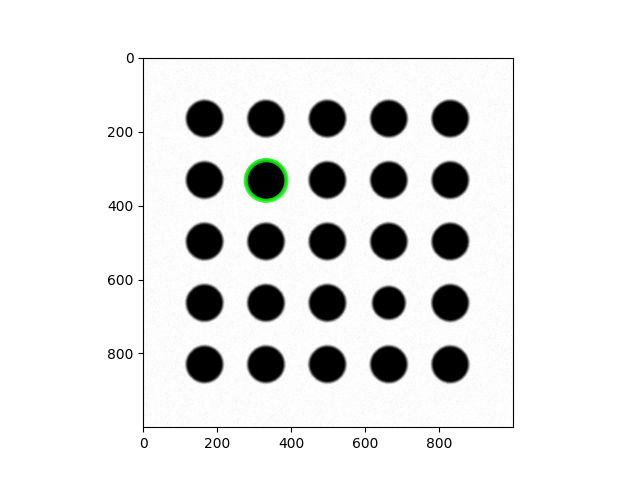

In [9]:
# Display image and detected circle

circRadius = 55
## Create figure object
fig, ax = plt.subplots(1,1)
ax.imshow(img, cmap='gray', vmin=0, vmax=255)

# Create circle
circle = matplotlib.patches.Circle((circPos_X, circPos_Y), circRadius, # Circle center as tuple and radius 
                color='lime',          # Cyan color
                linestyle='-',         # Solid line
                linewidth=3,           # Thicker line
                alpha=0.8,             # Slightly transparent
                fill=False)            # Do not fill the circle

# Add circle to image
ax.add_patch(circle)

# Display the image using imshow
plt.show()






### Glückwunsch zur erfolgreichen Implementierung Ihrer ersten Kreisdetektion mittels Hough Transformtation!

#### Weiteres Vorgehen:
Zum schluss sollen nun auch die Kreise mit den Radien 50 Pix. und 45 Pix. detektiert werden. Implementieren Sie dazu eine funktion `detectCircles(img, radius, threshold=0.9)`, die alle Schritte (Kantendetektion, Akkumulatorberechnung, Lokalisierung der Kreismittelpunkte) für einen gegebenen Radius durchführt und die detektierten Kreismittelpunkte zurückgibt. Rufen Sie diese Funktion dann für die Radien 50 Pix. und 45 Pix. auf und zeigen Sie die detektierten Kreise farblich markiert im Originalbild an.

In [10]:
def detectCircles(img, radius, threshold=0.9):
    """Detect circles of specific radius in image.
    
    Args:
        img: Grayscale input image.
        radius: Circle radius to detect.
        threshold: Accumulator threshold (0-1).
    
    Returns:
        Tuple of (y_positions, x_positions).
    """

    ####
    ### ENTER YOUR CODE HERE
    ####

    # canny edge detection
    img_edges = skimage.feature.canny(img, sigma=2)

    # create circle image
    img_circ = createCircleImage(radius)

    # calculate accumulator
    accumulator = calculateCircAccumulator(img_edges, img_circ)

    #filter circle positione
    detectedPositions_y, detectedPositions_x = np.nonzero(accumulator >= threshold*np.max(accumulator))

    return detectedPositions_y, detectedPositions_x

#### Berechniung der Kreismittelpunkte fuer Radius 55, 50 und 45 Pix.

Berechnen Sie die Kreismittelpunkte fuer die Radien 55, 50 und 45 Pix. und speichern Sie die x- und y-Koordinaten der Mittelpunkte in passenden Variablen ab.
Zeichnen Sie die die detektierten Kreise farblich markiert im Originalbild an.
Nutzen Sie hierfür dann wieder die Plotly Shape-Objekte. `.add_shape(...)`

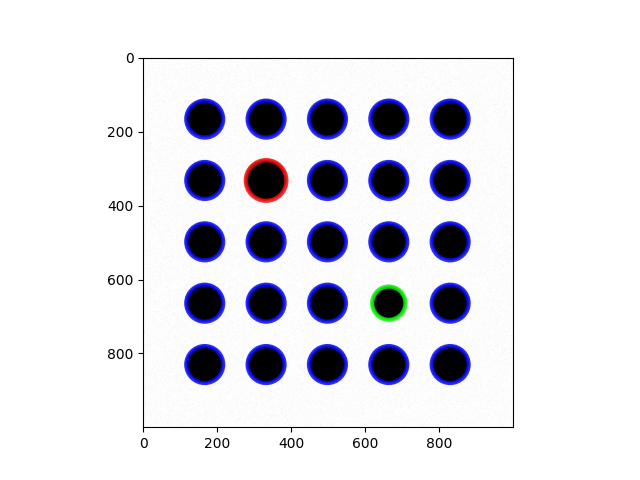

In [11]:
####
## ENTER YOUR CODE HERE
####



###### Matplotlib Visualization

fig, ax = plt.subplots(1,1)
ax.imshow(img, cmap='gray', vmin=0, vmax=255)

##########
# radius 50
# determine circle positions and display in figure
# color: blue
radius = 50
circPositions_y, circPositions_x = detectCircles(img, radius, threshold=0.9)

for center_y, center_x in zip(circPositions_y, circPositions_x):
    circle = matplotlib.patches.Circle((center_x, center_y), radius,
                color='blue',          # Cyan color
                linestyle='-',         # Solid line
                linewidth=3,           # Thicker line
                alpha=0.8,             # Slightly transparent
                fill=False)            # Do not fill the circle
    ax.add_patch(circle)



#############
# radius 55
# determine circle positions and display in figure
# color: red

radius = 55
circPositions_y, circPositions_x = detectCircles(img, radius, threshold=0.9)


for center_y, center_x in zip(circPositions_y, circPositions_x):
    circle = matplotlib.patches.Circle((center_x, center_y), radius,
                color='red',          # Cyan color
                linestyle='-',         # Solid line
                linewidth=3,           # Thicker line
                alpha=0.8,             # Slightly transparent
                fill=False)            # Do not fill the circle
    ax.add_patch(circle)


############
# radius 55
# determine circle positions and display in figure
# color: lime
radius = 45
circPositions_y, circPositions_x = detectCircles(img, radius, threshold=0.9)

for center_y, center_x in zip(circPositions_y, circPositions_x):
    circle = matplotlib.patches.Circle((center_x, center_y), radius,
                color='lime',          # Cyan color
                linestyle='-',         # Solid line
                linewidth=3,           # Thicker line
                alpha=0.8,             # Slightly transparent
                fill=False)            # Do not fill the circle
    ax.add_patch(circle)


# Display the image using imshow
plt.show()

